In [ ]:
import numpy as np

In [2]:
import pandas as pd

# 1. Load the Power data, stripping whitespace and dropping the empty trailing column
df_power = pd.read_csv('powwy.txt', skipinitialspace=True).dropna(axis=1, how='all')
df_power.columns = df_power.columns.str.strip()  # Clean up column names

# 2. Load the GS population data similarly
df_gs = pd.read_csv('poppy.txt', skipinitialspace=True).dropna(axis=1, how='all')
df_gs.columns = df_gs.columns.str.strip()  # Clean up column names

# Constants
N_l = 8       # number of QD layers
N_D = 5.9e10  # QD surface density

# 3. Merge the two datasets on the 'Time [ns]' column
combined_df = pd.merge(df_power, df_gs, on='Time [ns]')

# 4. Calculate and add rho_e as a new column in the combined dataframe
combined_df['rho_e'] = combined_df['GS pop. [18 cm^-3]']*1E18 * 40E-7 / (2*N_l * N_D)

combined_df['tau_e'] = 2/(1-combined_df['rho_e'])

# Print the full dataframe to see all columns including rho_e
print(combined_df)

       Time [ns]    Power [mW]  GS pop. [18 cm^-3]     rho_e     tau_e
0       0.000000  0.000000e+00            0.020309  0.086055  2.188315
1       0.001053  1.872690e-08            0.027475  0.116421  2.263522
2       0.002106  9.575810e-08            0.034085  0.144427  2.337614
3       0.003159  2.287930e-07            0.040021  0.169581  2.408423
4       0.004212  3.511500e-07            0.045256  0.191765  2.474527
...          ...           ...                 ...       ...       ...
47481  49.995500  7.461730e-06            0.142948  0.605712  5.072433
47482  49.996500  7.364050e-06            0.142920  0.605593  5.070907
47483  49.997600  6.191070e-06            0.142892  0.605475  5.069382
47484  49.998600  6.427280e-06            0.142864  0.605356  5.067858
47485  49.999700  7.765950e-06            0.142836  0.605237  5.066335

[47486 rows x 5 columns]


In [9]:
print(0.71*1E18*40E-7 / (6*N_l * N_D))

1.002824858757062


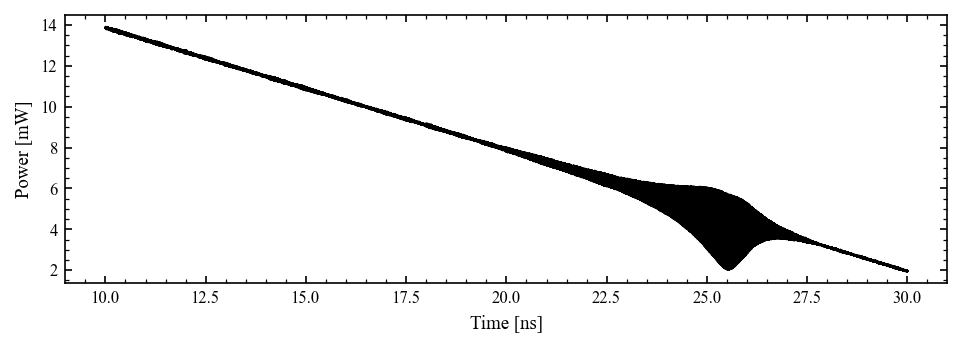

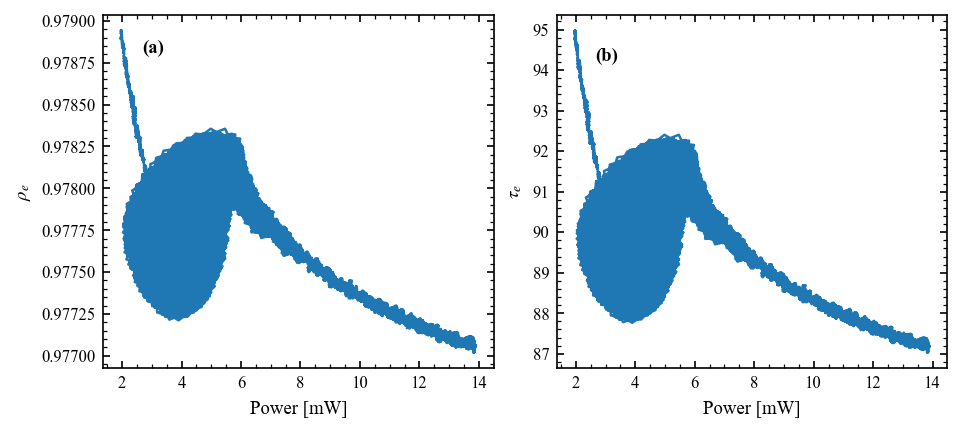

In [ ]:
import matplotlib.pyplot as plt

# 1. Create the boolean mask (returns True for rows > 5)

# Fixed mask with parentheses and &
mask = (combined_df['Time [ns]'] > 10) & (combined_df['Time [ns]'] < 30)

# 2. Apply the mask to filter the dataframe
filtered_df = combined_df[mask]
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------------------------------------------------
# Publication style settings
# ----------------------------------------------------------------------
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',        # LaTeX-like math without requiring LaTeX
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

TEXT_WIDTH = 6.3  # inches, full text width of the document

# ----------------------------------------------------------------------
# 1. Filter data
# ----------------------------------------------------------------------
mask = (combined_df['Time [ns]'] > 10) & (combined_df['Time [ns]'] < 30)
filtered_df = combined_df[mask]

# ----------------------------------------------------------------------
# 2. Figure 1: Power vs Time (single panel, full text width)
# ----------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(TEXT_WIDTH, TEXT_WIDTH * 0.35),
                          constrained_layout=True)

ax1.plot(filtered_df['Time [ns]'], filtered_df['Power [mW]'], color='k')
ax1.set_xlabel('Time [ns]')
ax1.set_ylabel('Power [mW]')

fig1.savefig('power_vs_time.pdf', bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 3. Figure 2: rho and tau vs Power, side by side
# ----------------------------------------------------------------------
fig2, (ax2, ax3) = plt.subplots(
    1, 2,
    figsize=(TEXT_WIDTH, TEXT_WIDTH * 0.44),
    constrained_layout=True
)

ax2.plot(filtered_df['Power [mW]'], filtered_df['rho_e'], color='C0')
ax2.set_xlabel('Power [mW]')
ax2.set_ylabel(r'$\rho_e$')
ax2.text(0.1, 0.93, '(a)', transform=ax2.transAxes,
          fontsize=9, fontweight='bold', va='top')

ax3.plot(filtered_df['Power [mW]'], filtered_df['tau_e'], color='C0')
ax3.set_xlabel('Power [mW]')
ax3.set_ylabel(r'$\tau_e$')
ax3.text(0.1, 0.91, '(b)', transform=ax3.transAxes,
          fontsize=9, fontweight='bold', va='top')

fig2.savefig('power_rho_tau.pdf', bbox_inches='tight')
plt.show()